In [1]:
import pandas as pd
import numpy as np
import shap
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Load saved model
model = pickle.load(open('model.pkl', 'rb'))

print("Model loaded!")
print(f"Model has {model.n_estimators} trees")

Model loaded!
Model has 200 trees


In [3]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df = df.drop(columns=['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18'])

X = df.drop(columns=['Attrition'])
y = df['Attrition'].map({'Yes': 1, 'No': 0})

le = LabelEncoder()
text_columns = X.select_dtypes(include='str').columns.tolist()
for col in text_columns:
    X[col] = le.fit_transform(X[col])

scaler = pickle.load(open('scaler.pkl', 'rb'))
numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
X[numerical_columns] = scaler.transform(X[numerical_columns])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data ready!")

Data ready!


In [4]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP explainer created!")

SHAP values shape: (294, 30)
SHAP explainer created!


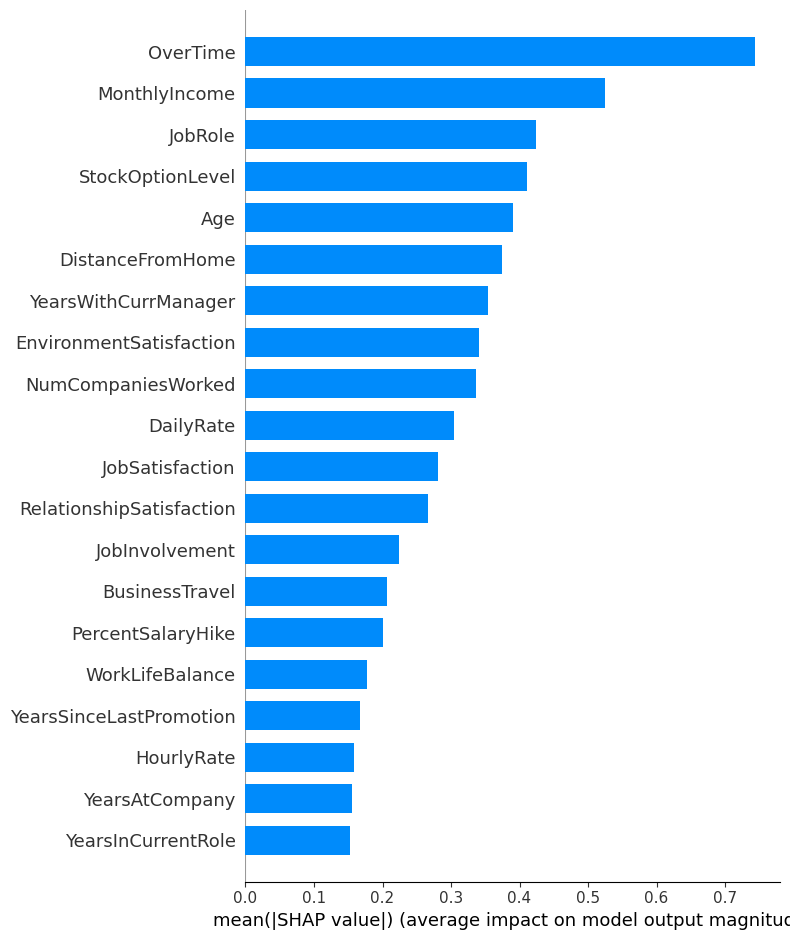

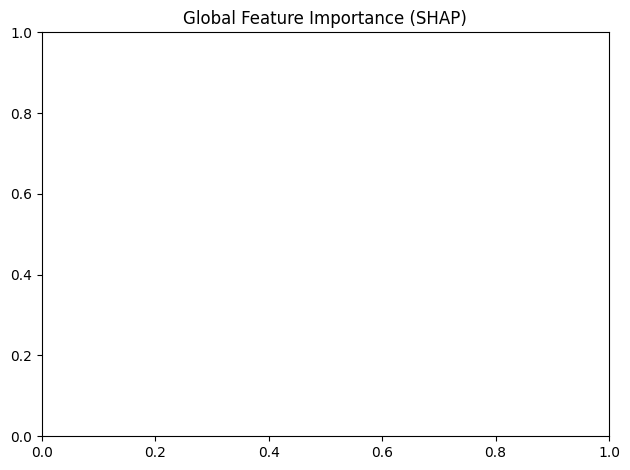

In [8]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, 
                  feature_names=X_test.columns.tolist(),
                  plot_type="bar")
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

In [9]:
shap_importance = pd.DataFrame({
    'feature': X_test.columns.tolist(),
    'importance': np.abs(shap_values).mean(axis=0)
})
shap_importance = shap_importance.sort_values('importance', ascending=False)
print(shap_importance.to_string())

                     feature  importance
18                  OverTime    0.742960
15             MonthlyIncome    0.524399
12                   JobRole    0.424330
22          StockOptionLevel    0.410742
0                        Age    0.389760
4           DistanceFromHome    0.374728
29      YearsWithCurrManager    0.354610
7    EnvironmentSatisfaction    0.340711
17        NumCompaniesWorked    0.336887
2                  DailyRate    0.303771
13           JobSatisfaction    0.280273
21  RelationshipSatisfaction    0.266095
10            JobInvolvement    0.224791
1             BusinessTravel    0.206615
19         PercentSalaryHike    0.200492
25           WorkLifeBalance    0.177109
28   YearsSinceLastPromotion    0.166724
9                 HourlyRate    0.157729
26            YearsAtCompany    0.155984
27        YearsInCurrentRole    0.152893
16               MonthlyRate    0.151646
23         TotalWorkingYears    0.135495
14             MaritalStatus    0.116905
5               

In [10]:
print(df['PerformanceRating'].value_counts())

PerformanceRating
3    1244
4     226
Name: count, dtype: int64


In [11]:
# Pick the first employee in test set
employee_index = 0

# Get their probability
prob = model.predict_proba(X_test.iloc[[employee_index]])[0][1]
prediction = "Will Leave" if prob >= 0.3 else "Will Stay"

print(f"Employee {employee_index}:")
print(f"Prediction: {prediction}")
print(f"Flight Risk: {prob:.1%}")
print(f"\nTop factors driving this prediction:")

# Get SHAP values for this employee
employee_shap = shap_values[employee_index]
feature_names = X_test.columns.tolist()

# Create a dataframe of feature contributions
shap_df = pd.DataFrame({
    'feature': feature_names,
    'shap_value': employee_shap,
    'actual_value': X_test.iloc[employee_index].values
})

# Sort by absolute impact
shap_df['abs_impact'] = shap_df['shap_value'].abs()
shap_df = shap_df.sort_values('abs_impact', ascending=False)

# Show top 5 factors
for _, row in shap_df.head(5).iterrows():
    direction = "↑ increases risk" if row['shap_value'] > 0 else "↓ decreases risk"
    print(f"  {row['feature']:<25} {direction} (impact: {row['shap_value']:.3f})")

Employee 0:
Prediction: Will Leave
Flight Risk: 38.3%

Top factors driving this prediction:
  MonthlyIncome             ↑ increases risk (impact: 1.411)
  YearsWithCurrManager      ↑ increases risk (impact: 1.213)
  BusinessTravel            ↓ decreases risk (impact: -1.076)
  OverTime                  ↓ decreases risk (impact: -0.872)
  TotalWorkingYears         ↑ increases risk (impact: 0.594)


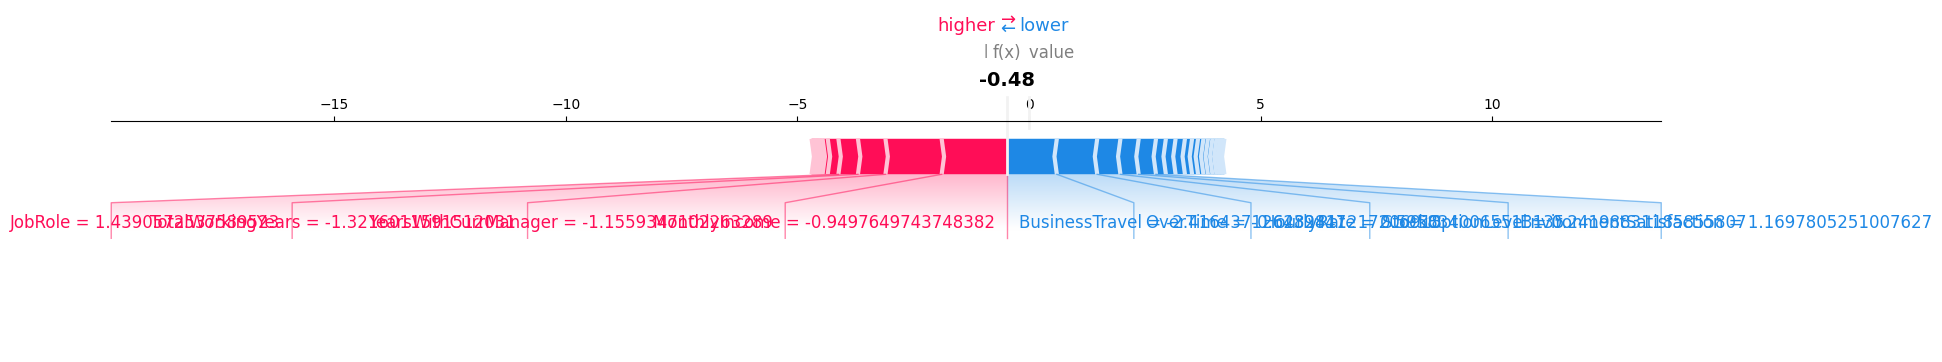

<Figure size 640x480 with 0 Axes>

In [12]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[employee_index],
    X_test.iloc[employee_index],
    feature_names=X_test.columns.tolist(),
    matplotlib=True
)
plt.tight_layout()
plt.show()